<a href="https://colab.research.google.com/github/24cseaiml156jyotiranjanmohakud/DMPM-LAB-REPO/blob/main/DMPM_LAB_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Means and K-Medoid Clustering**

In [3]:
!pip install scikit-learn-extra
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler

In [4]:
np.random.seed(42)
n_samples = 300

In [5]:
income_g1 = np.random.normal(30, 5, 100)
spending_g1 = np.random.normal(80, 5, 100)

income_g2 = np.random.normal(100, 10, 100)
spending_g2 = np.random.normal(20, 8, 100)

income_g3 = np.random.normal(60, 8, 100)
spending_g3 = np.random.normal(50, 7, 100)

In [6]:
df = pd.DataFrame({
    'Annual_Income_K': np.concatenate([income_g1, income_g2, income_g3]),
    'Spending_Score': np.concatenate([spending_g1, spending_g2, spending_g3])
})

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [8]:
num_clusters = 3

In [9]:
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [10]:
kmedoids = KMedoids(n_clusters=num_clusters, random_state=42)
df['KMedoids_Cluster'] = kmedoids.fit_predict(X_scaled)

In [11]:
print("--- First 5 Customers and their Cluster Assignments ---")
print(df[['Annual_Income_K', 'Spending_Score', 'KMeans_Cluster', 'KMedoids_Cluster']].head())

--- First 5 Customers and their Cluster Assignments ---
   Annual_Income_K  Spending_Score  KMeans_Cluster  KMedoids_Cluster
0        32.483571       72.923146               1                 1
1        29.308678       77.896773               1                 1
2        33.238443       78.286427               1                 1
3        37.615149       75.988614               1                 1
4        28.829233       79.193571               1                 1


In [12]:
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)
kmedoids_centers = scaler.inverse_transform(kmedoids.cluster_centers_)

print("\n--- K-Means Calculated Centers (Averages) ---")
for i, center in enumerate(kmeans_centers):
    print(f"Cluster {i}: Income = ${center[0]:.1f}K, Spending Score = {center[1]:.1f}")

print("\n--- K-Medoids Selected Centers (Actual Customers) ---")
for i, center in enumerate(kmedoids_centers):
    print(f"Cluster {i}: Income = ${center[0]:.1f}K, Spending Score = {center[1]:.1f}")


--- K-Means Calculated Centers (Averages) ---
Cluster 0: Income = $100.5K, Spending Score = 21.0
Cluster 1: Income = $29.5K, Spending Score = 80.1
Cluster 2: Income = $59.3K, Spending Score = 49.3

--- K-Medoids Selected Centers (Actual Customers) ---
Cluster 0: Income = $57.8K, Spending Score = 49.5
Cluster 1: Income = $29.8K, Spending Score = 79.6
Cluster 2: Income = $100.5K, Spending Score = 20.6


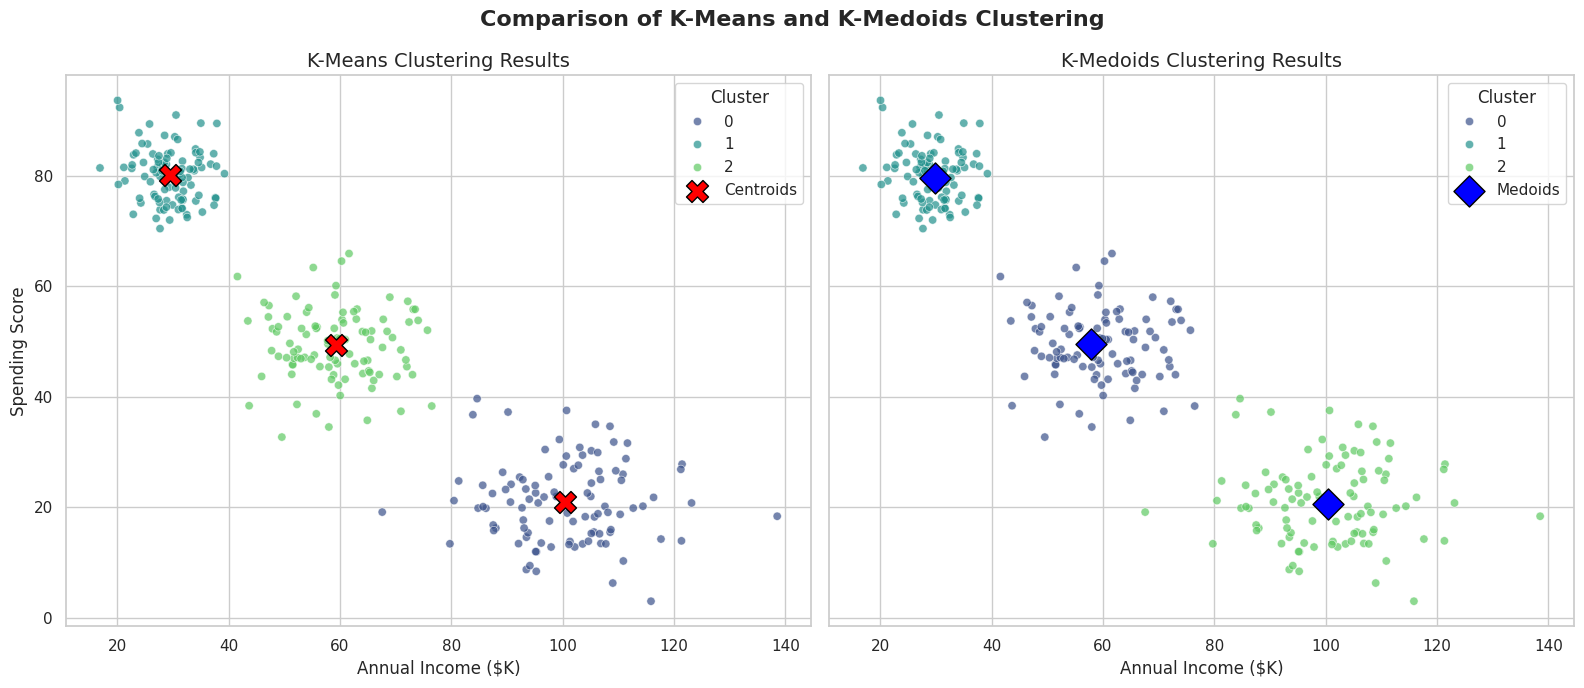

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Define a palette for clusters
palette = sns.color_palette("viridis", as_cmap=False, n_colors=num_clusters)

# 1. Plot K-Means Clustering
sns.scatterplot(
    ax=axes[0],
    data=df,
    x='Annual_Income_K',
    y='Spending_Score',
    hue='KMeans_Cluster',
    palette=palette,
    legend='full',
    alpha=0.7
)
# Plot K-Means centers
axes[0].scatter(
    kmeans_centers[:, 0],
    kmeans_centers[:, 1],
    color='red',
    s=250,
    marker='X',
    edgecolors='black',
    label='Centroids'
)
axes[0].set_title('K-Means Clustering Results', fontsize=14)
axes[0].set_xlabel('Annual Income ($K)', fontsize=12)
axes[0].set_ylabel('Spending Score', fontsize=12)
axes[0].legend(title='Cluster')

# 2. Plot K-Medoids Clustering
sns.scatterplot(
    ax=axes[1],
    data=df,
    x='Annual_Income_K',
    y='Spending_Score',
    hue='KMedoids_Cluster',
    palette=palette,
    legend='full',
    alpha=0.7
)
# Plot K-Medoids centers (medoids)
axes[1].scatter(
    kmedoids_centers[:, 0],
    kmedoids_centers[:, 1],
    color='blue',
    s=250,
    marker='D',
    edgecolors='black',
    label='Medoids'
)
axes[1].set_title('K-Medoids Clustering Results', fontsize=14)
axes[1].set_xlabel('Annual Income ($K)', fontsize=12)
axes[1].set_ylabel('Spending Score', fontsize=12)
axes[1].legend(title='Cluster')

plt.suptitle('Comparison of K-Means and K-Medoids Clustering', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()